**Import Libraries**

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torch.utils.data import TensorDataset
from torch.utils.data import Dataset
from torch.nn.utils.rnn import pad_sequence
import matplotlib.pyplot as plt
from tqdm.auto import trange
import os
import random


**Parameters for data preprocessing**

In [18]:
# Number of file to pick in both training and development set
num_files_to_pick = 5000

**Preprocessing of training data** 

In [19]:
# Set the directory containing the .pt files for the TRAINING SET
data_dir = 'C:/Users/felip/teamlab-phonetics/feature_extraction/mel_segment_outputs/tensors_training_set'

# Set the number of files to pick and the random seed
#random_seed = 42

# List all .pt files in the directory
all_files = [f for f in os.listdir(data_dir) if f.endswith('.pt')]

# Set the random seed for reproducibility
#random.seed(random_seed)

# Randomly select the specified number of files
selected_files = random.sample(all_files, num_files_to_pick)

# Inspect a single .pt file before loading into classes
inspect_file = os.path.join(data_dir, selected_files[0])  # Select the first file from the random selection

# Inspect the data from the .pt file
inspect_data = torch.load(inspect_file)
print("Example of the .pt file",inspect_data[0])

# Initialize a list to store the features and labels
features_list = []
labels_list = []

# Load the features and labels for the selected .pt files
for file_name in selected_files:
    file_path = os.path.join(data_dir, file_name)
    feature, label = torch.load(file_path)
    features_list.append(feature)  # Append the tensors
    labels_list.append(label) # Append the labels

# Concatenate all the data into a single tensor
features = torch.stack(features_list)
print("Example of the features",features[1])
labels = torch.tensor(labels_list)
print("Example of the labels",labels)

# Debugging: Check the shapes of features and labels
print("Features shape:", features.shape)
print("Labels shape:", labels.shape)

# Create a TensorDataset and DataLoader
dataset = TensorDataset(features, labels)
dataLoader = DataLoader(dataset, batch_size=32, shuffle=True)
print("The training dataset has been successfully loaded into DataLoader.")

Example of the .pt file tensor([[-64.5990, -70.1881, -80.0000,  ..., -80.0000, -80.0000, -80.0000],
        [-61.8474, -67.3854, -80.0000,  ..., -80.0000, -79.7717, -74.1493],
        [-51.7587, -49.4869, -50.8788,  ..., -50.2500, -52.8216, -58.3155],
        ...,
        [-80.0000, -80.0000, -80.0000,  ..., -80.0000, -80.0000, -80.0000],
        [-80.0000, -80.0000, -80.0000,  ..., -80.0000, -80.0000, -80.0000],
        [-80.0000, -80.0000, -80.0000,  ..., -80.0000, -80.0000, -80.0000]])
Example of the features tensor([[-60.3773, -66.7296, -80.0000,  ..., -73.3404, -61.2716, -55.1779],
        [-58.4370, -64.3989, -79.4501,  ..., -60.0041, -54.4409, -50.0249],
        [-50.5491, -48.8428, -47.1658,  ..., -34.3438, -44.3908, -43.2672],
        ...,
        [-80.0000, -80.0000, -80.0000,  ..., -78.4754, -65.9577, -64.8514],
        [-80.0000, -80.0000, -80.0000,  ..., -80.0000, -74.0333, -73.0814],
        [-80.0000, -80.0000, -80.0000,  ..., -80.0000, -80.0000, -80.0000]])
Example of t

**Dataset inspection**

In [20]:
# Inspect the range of labels in the dataset
#print("Minimum label value:", labels.min().item())
#print("Maximum label value:", labels.max().item())
#print("Unique label values:", torch.unique(labels))

# Inspect the first sample in the batch
print("First sample shape:", features[0].shape)
print("First sample values:\n", features[0])


# Inspect the concatenated tensor
#print("Data Tensor Shape:", data_tensor.shape)
#print("Data Tensor Data Type:", data_tensor.dtype)
#print("Sample Data Tensor Values:\n", data_tensor[:5])  # Print the first 5 rows

# Inspect features and labels
#print("Features Shape:", features.shape)
#print("Labels Shape:", labels.shape)
#print("Sample Features:\n", features[:5])  # Print the first 5 rows of features
print("Sample Labels:\n", labels[:100])  # Print the first 5 labels

First sample shape: torch.Size([128, 126])
First sample values:
 tensor([[-64.5990, -70.1881, -80.0000,  ..., -80.0000, -80.0000, -80.0000],
        [-61.8474, -67.3854, -80.0000,  ..., -80.0000, -79.7717, -74.1493],
        [-51.7587, -49.4869, -50.8788,  ..., -50.2500, -52.8216, -58.3155],
        ...,
        [-80.0000, -80.0000, -80.0000,  ..., -80.0000, -80.0000, -80.0000],
        [-80.0000, -80.0000, -80.0000,  ..., -80.0000, -80.0000, -80.0000],
        [-80.0000, -80.0000, -80.0000,  ..., -80.0000, -80.0000, -80.0000]])
Sample Labels:
 tensor([1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0,
        1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
        0, 1, 0, 0])


**Testing the Data Loader**

In [ ]:
print(len(dataset[0][0]))
print(features.shape)

#for batch in dataLoader:
#    features, labels = batch
#    print("Batch features shape:", features.shape)
#    break

128
torch.Size([5000, 128, 126])
Batch features shape: torch.Size([32, 128, 126])


**Preprocessing and loading the Development/Validation Set**

In [34]:
# Set the directory containing the .pt files for the VALIDATION SET
dev_data_dir = 'C:/Users/felip/teamlab-phonetics/feature_extraction/mel_segment_outputs/tensors_dev_set'

# Set the number of files to pick and the random seed
#random_seed = 42

# List all .pt files in the directory
all_files = [f for f in os.listdir(dev_data_dir) if f.endswith('.pt')]

# Set the random seed for reproducibility
#random.seed(random_seed)

# Randomly select the specified number of files
selected_files = random.sample(all_files, num_files_to_pick)

# Inspect a single .pt file before loading into classes
inspect_file = os.path.join(dev_data_dir, selected_files[0])  # Select the first file from the random selection

# Inspect the data from the .pt file
inspect_data = torch.load(inspect_file)
print("Example of the .pt file",inspect_data[0])

# Initialize a list to store the features and labels
dev_features_list = []
dev_labels_list = []

# Load the features and labels for the selected .pt files
for file_name in selected_files:
    file_path = os.path.join(dev_data_dir, file_name)
    dev_feature, dev_label = torch.load(file_path)
    dev_features_list.append(dev_feature)  # Append the tensors
    dev_labels_list.append(dev_label) # Append the labels

# Concatenate all the data into a single tensor
dev_features = torch.stack(dev_features_list)
print("Example of the features",dev_features[1])
dev_labels = torch.tensor(dev_labels_list)
print("Example of the labels",dev_labels)

# Debugging: Check the shapes of features and labels
print("Features shape:", dev_features.shape)
print("Labels shape:", dev_labels.shape)

# Create a TensorDataset and DataLoader
dev_dataset = TensorDataset(dev_features, dev_labels)
dev_dataLoader = DataLoader(dev_dataset, batch_size=32, shuffle=False)
print("The development dataset has been successfully loaded into DataLoader.")

Example of the .pt file tensor([[-60.0337, -65.7604, -80.0000,  ..., -80.0000, -80.0000, -77.5681],
        [-57.8130, -63.4748, -80.0000,  ..., -80.0000, -80.0000, -75.1035],
        [-51.7992, -52.9869, -61.6219,  ..., -59.6136, -65.9571, -70.8785],
        ...,
        [-80.0000, -80.0000, -79.7463,  ..., -39.3790, -39.5851, -48.6683],
        [-80.0000, -80.0000, -80.0000,  ..., -43.9870, -45.1037, -53.7463],
        [-80.0000, -80.0000, -80.0000,  ..., -57.3581, -56.4356, -63.6092]])
Example of the features tensor([[-63.8526, -68.7003, -80.0000,  ..., -80.0000, -77.4398, -72.9411],
        [-59.8462, -64.8120, -80.0000,  ..., -79.1905, -71.5399, -68.5774],
        [-50.0917, -50.1246, -58.5590,  ..., -47.1134, -54.0964, -57.1098],
        ...,
        [-80.0000, -80.0000, -72.2300,  ..., -47.2450, -60.1583, -80.0000],
        [-80.0000, -80.0000, -73.7856,  ..., -51.0667, -64.3589, -80.0000],
        [-80.0000, -80.0000, -80.0000,  ..., -66.5232, -80.0000, -80.0000]])
Example of t

**Testing the Processed Dataloaders and Label Distribution**

In [43]:
print("Training features shape",features.shape)
print("Training labels shape",labels.shape)
print("Development features shape:", dev_features.shape)
print("Development labels shape:", dev_labels.shape)

print("Training label distribution:", torch.bincount(labels))
print("Validation label distribution:", torch.bincount(dev_labels))

Training features shape torch.Size([8, 128, 126])
Training labels shape torch.Size([8])
Development features shape: torch.Size([5000, 128, 126])
Development labels shape: torch.Size([5000])
Training label distribution: tensor([5, 3], device='cuda:0')
Validation label distribution: tensor([4448,  552])


**Hyperparemeters**

In [35]:
hidden_dim = 128  # Number of neurons in the hidden layer
dropout_prob = 0.5  # Dropout probability

**Neural Network Model**

In [36]:
class SpoofDetectionModel(nn.Module):
    def __init__(self, hidden_dim, dropout_prob=0.5):
        super(SpoofDetectionModel, self).__init__()
        
        # 1D Convolutional layers
        self.conv1 = nn.Conv1d(in_channels=126, out_channels=32, kernel_size=3, stride=1, padding=1)
        self.conv2 = nn.Conv1d(in_channels=32, out_channels=64, kernel_size=3, stride=1, padding=1)
        self.pool = nn.MaxPool1d(kernel_size=2, stride=2, padding=0)
        
        # Dropout layer
        self.dropout = nn.Dropout(dropout_prob)
        
        # Fully connected layers
        self.fc1 = None  # Placeholder, will be initialized dynamically
        self.fc3 = nn.Linear(hidden_dim, 1)  # Single output neuron for binary classification
        
        # Initialize weights
        self.init_weights()
        
    def init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv1d) or isinstance(m, nn.Linear):
                torch.nn.init.kaiming_uniform_(m.weight, mode='fan_in', nonlinearity='relu')
                if m.bias is not None:
                    torch.nn.init.zeros_(m.bias)
        
    def forward(self, x):
        # Debugging: Print the input tensor shape before passing to the model
        #print("Input tensor shape before permute:", x.shape)
        
        # Permute input to (batch_size, num_channels, sequence_length)
        x = x.permute(0, 2, 1)
        #print("Input tensor shape after permute:", x.shape)
        
        # Convolutional layers
        x = self.pool(torch.relu(self.conv1(x)))
        x = self.pool(torch.relu(self.conv2(x)))
        x = self.dropout(x)  # Apply dropout after convolutional layers
        
        # Flatten the output for the fully connected layer
        x = x.view(x.size(0), -1)
        
        # Dynamically initialize fc1 if not already done
        if self.fc1 is None:
            self.fc1 = nn.Linear(x.size(1), hidden_dim).to(x.device)
        
        x = torch.relu(self.fc1(x))
        x = self.dropout(x)  # Apply dropout after the first fully connected layer
        x = torch.sigmoid(self.fc3(x))  # Output layer: Sigmoid for binary classification
        
        return x

**Initializing the model**

In [55]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = SpoofDetectionModel(hidden_dim, dropout_prob).to(device)

**Loss function and Optimizer**

In [56]:
criterion = nn.BCELoss()  # Binary cross-entropy loss
optimizer = optim.Adam(model.parameters(), lr=0.0001, weight_decay=1e-5)  # Learning rate + weight decay

**Metric Initialization / Learning Scheduler / Early stopping**

In [57]:
import matplotlib.pyplot as plt

# Initialize lists to store metrics
losses_train = [] # Stores the average training loss for each epoch.
losses_val = [] # Stores the average validation loss for each epoch.
accuracies_train = [] # Stores the training accuracy for each epoch.
accuracies_val = [] # Stores the validation accuracy for each epoch.

### Learning rate scheduler to reduce the learning rate during training
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=3)

# Initialize variables for early stopping
best_val_loss = float('inf')  # Track the best validation loss
patience = 10  # Number of epochs to wait for improvement
counter = 0   # Counter for early stopping


**Training Loop**

In [58]:
# Training loop
num_epochs = 30
for epoch in range(num_epochs):
    model.train()  # Set model to training mode
    epoch_loss_train = 0.0
    correct_train = 0
    total_train = 0
    
    # Training phase
    for batch_idx, (features, labels) in enumerate(dataLoader):
        features, labels = features.to(device), labels.to(device)
        
        # Forward pass
        outputs = model(features)
        loss = criterion(outputs, labels.float().unsqueeze(1))  # Reshape labels to [batch_size, 1]
        
        # Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        # Accumulate training loss and accuracy
        epoch_loss_train += loss.item()
        predicted = (outputs > 0.5).float()
        total_train += labels.size(0)
        correct_train += (predicted.squeeze() == labels).sum().item()
    
    # Compute average training loss and accuracy for the epoch
    avg_loss_train = epoch_loss_train / len(dataLoader)
    accuracy_train = 100 * correct_train / total_train
    losses_train.append(avg_loss_train)
    accuracies_train.append(accuracy_train)
    
################# VALIDATION PHASE #####################
    model.eval()  # Set model to evaluation mode
    epoch_loss_val = 0.0
    correct_val = 0
    total_val = 0
    
    with torch.no_grad():
        for features, labels in dev_dataLoader:
            features, labels = features.to(device), labels.to(device)
            outputs = model(features)
            loss = criterion(outputs, labels.float().unsqueeze(1))  # Reshape labels to [batch_size, 1]
            
            # Accumulate validation loss and accuracy
            epoch_loss_val += loss.item()
            predicted = (outputs > 0.5).float()
            correct_val += (predicted.squeeze() == labels).sum().item()
            total_val += labels.size(0)
    
    # Compute average validation loss and accuracy for the epoch
    avg_loss_val = epoch_loss_val / len(dev_dataLoader)
    accuracy_val = 100 * correct_val / total_val
    losses_val.append(avg_loss_val)
    accuracies_val.append(accuracy_val)
    
    # Print metrics for the epoch
    print(f'Epoch [{epoch+1}/{num_epochs}], '
          f'Train Loss: {avg_loss_train:.4f}, Train Accuracy: {accuracy_train:.2f}%, '
          f'Val Loss: {avg_loss_val:.4f}, Val Accuracy: {accuracy_val:.2f}%')
    
    # Learning rate scheduling
    scheduler.step(avg_loss_val)  # Adjust learning rate based on validation loss
    
    # Early stopping
    if avg_loss_val < best_val_loss:
        best_val_loss = avg_loss_val
        counter = 0
        torch.save(model.state_dict(), 'best_model.pth')  # Save the best model
    else:
        counter += 1
        if counter >= patience:
            print("Early stopping triggered.")
            break

Epoch [1/30], Train Loss: 28.0690, Train Accuracy: 52.78%, Val Loss: 1.7861, Val Accuracy: 88.96%
Epoch [2/30], Train Loss: 2.8459, Train Accuracy: 74.64%, Val Loss: 0.5211, Val Accuracy: 88.86%
Epoch [3/30], Train Loss: 0.5580, Train Accuracy: 81.12%, Val Loss: 0.3506, Val Accuracy: 88.72%
Epoch [4/30], Train Loss: 0.4364, Train Accuracy: 84.40%, Val Loss: 0.3445, Val Accuracy: 88.88%
Epoch [5/30], Train Loss: 0.4210, Train Accuracy: 85.68%, Val Loss: 0.3436, Val Accuracy: 88.92%
Epoch [6/30], Train Loss: 0.3978, Train Accuracy: 86.08%, Val Loss: 0.3354, Val Accuracy: 88.96%
Epoch [7/30], Train Loss: 0.3891, Train Accuracy: 86.02%, Val Loss: 0.3309, Val Accuracy: 88.96%
Epoch [8/30], Train Loss: 0.3633, Train Accuracy: 87.46%, Val Loss: 0.3306, Val Accuracy: 88.96%
Epoch [9/30], Train Loss: 0.3622, Train Accuracy: 87.88%, Val Loss: 0.3279, Val Accuracy: 88.96%
Epoch [10/30], Train Loss: 0.3566, Train Accuracy: 88.24%, Val Loss: 0.3247, Val Accuracy: 88.96%
Epoch [11/30], Train Loss: 0

**Plotting the results**

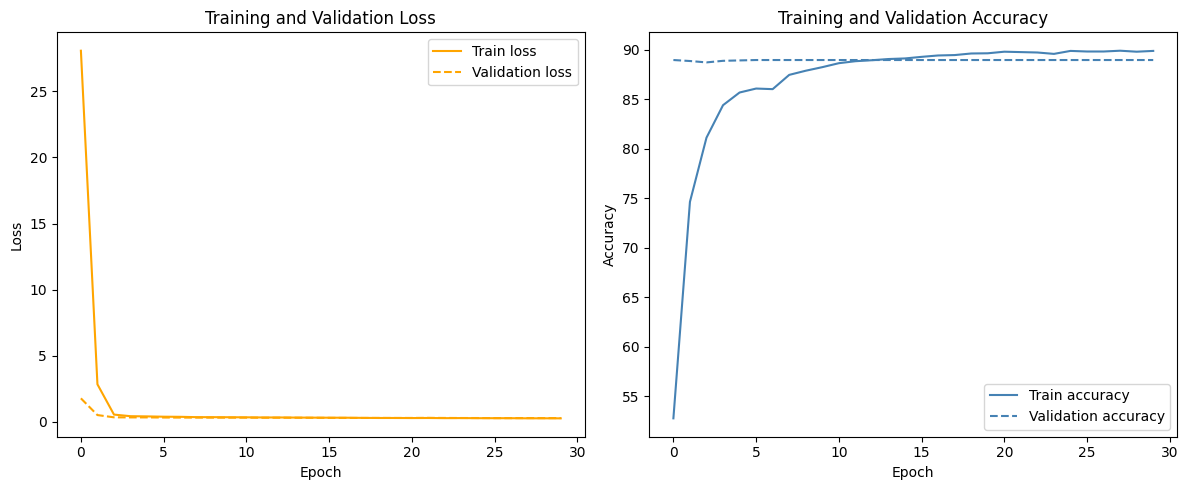

In [60]:
import matplotlib.pyplot as plt

# Plot training and validation loss
plt.figure(figsize=(12, 5))

# Loss plot
plt.subplot(1, 2, 1)
plt.plot(losses_train, color="orange", linestyle="-", label="Train loss")
plt.plot(losses_val, color="orange", linestyle="--", label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()

# Accuracy plot
plt.subplot(1, 2, 2)
plt.plot(accuracies_train, color="steelblue", linestyle="-", label="Train accuracy")
plt.plot(accuracies_val, color="steelblue", linestyle="--", label="Validation accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

**Saving the model**

In [61]:
torch.save(model.state_dict(), 'deepfake_audio_detection_model.pth')

**Testing the model in the Test Set - NEEDS MODIFICATION TO THE NEW DATASET (THIS IS FROM DL CODING TASK)**

In [ ]:
### WILL BE MODIFIED LATER - THIS IS FROM DL CODING TASK ###

# Load test data
test_data = json.load(open('ser_test_2.json', 'r'))

# Preprocess test data
test_features = [torch.tensor(sample["features"]) for sample in test_data.values()]

# Pad the test features to the same length as the training set (1707)
target_length = 1707  # Same as training set
test_padded_features = torch.zeros(len(test_features), target_length, 26)  # Initialize with zeros

# Use the same padding value as the training data (e.g., mean_value)
for i, feature in enumerate(test_features):
    seq_length = feature.size(0)
    if seq_length <= target_length:
        # Pad with the mean value if the sequence is shorter
        test_padded_features[i, :seq_length, :] = feature
        test_padded_features[i, seq_length:, :] = mean_value  # Fill the rest with the mean value
    else:
        # Truncate if the sequence is longer
        test_padded_features[i, :, :] = feature[:target_length, :]

# Normalize the features using the training data's mean and std
#test_padded_features = (test_padded_features - mean) / std

# Create a DataLoader for the test set
test_dataset = TensorDataset(test_padded_features)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# Make predictions
model.eval()  # Set model to evaluation mode
predictions_dict = {}

with torch.no_grad():
    for i, features in enumerate(test_loader):
        features = features[0].to(device)
        outputs = model(features)
        predicted = (outputs > 0.5).float().cpu().numpy()  # Convert probabilities to binary predictions
        
        # Format predictions
        for j, pred in enumerate(predicted):
            sample_id = str(i * 32 + j)  # Assuming batch size of 32
            predictions_dict[sample_id] = {
                "valence": int(pred[1]),  # Valence prediction
                "activation": int(pred[0])  # Activation prediction
            }

# Save predictions to a JSON file
with open('predictions_ultimate_model.json', 'w') as f:
    json.dump(predictions_dict, f, indent=4)

print("Predictions saved with success")

Predictions saved with success


In [15]:
unique_ids = list(test_data.keys())
print(unique_ids)

['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '40', '41', '42', '43', '44', '45', '46', '47', '48', '49', '50', '51', '52', '53', '54', '55', '56', '57', '58', '59', '60', '61', '62', '63', '64', '65', '66', '67', '68', '69', '70', '71', '72', '73', '74', '75', '76', '77', '78', '79', '80', '81', '82', '83', '84', '85', '86', '87', '88', '89', '90', '91', '92', '93', '94', '95', '96', '97', '98', '99', '100', '101', '102', '103', '104', '105', '106', '107', '108', '109', '110', '111', '112', '113', '114', '115', '116', '117', '118', '119', '120', '121', '122', '123', '124', '125', '126', '127', '128', '129', '130', '131', '132', '133', '134', '135', '136', '137', '138', '139', '140', '141', '142', '143', '144', '145', '146', '147', '148', '149', '150', '151', '152', '153', '154', '155', '156', '157', '15